<a href="https://colab.research.google.com/github/brittanybee-alt/Python-Statistics-in-EDA---Brittany-Barrion-/blob/main/Case_Study_Boston_Housing_%5BBrittany_Barrion%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [2]:
bos = pd.read_csv('/content/boston.csv')
print(bos.shape)
bos.head()

(506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [3]:
bos = bos.rename(columns={"MEDV":"PRICE"})
bos.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [4]:
bos.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


Text(0.5, 1.0, 'Relationship between CRIM and Price')

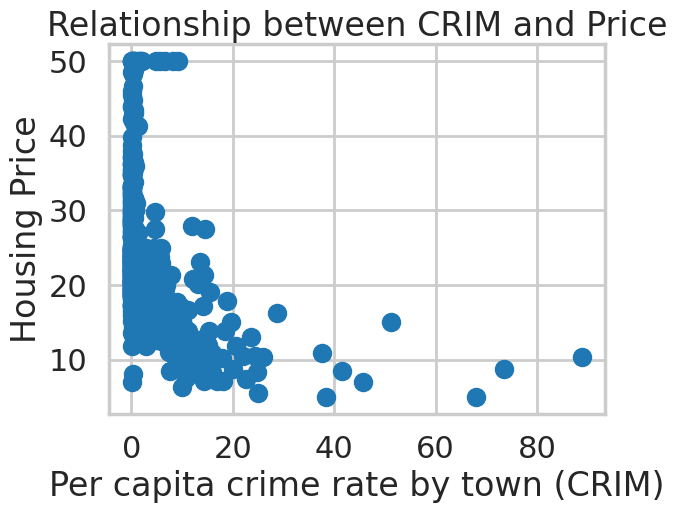

In [5]:
plt.scatter(bos.CRIM, bos.PRICE)
plt.xlabel("Per capita crime rate by town (CRIM)")
plt.ylabel("Housing Price")
plt.title("Relationship between CRIM and Price")

Part 2 Checkup Exercise Set I
Exercise: What kind of relationship do you see? e.g. positive, negative? linear? non-linear? Is there anything else strange or interesting about the data? What about outliers?

Exercise: Create scatter plots between *RM* and *PRICE*, and *PTRATIO* and *PRICE*. Label your axes appropriately using human readable labels. Tell a story about what you see.

Exercise: What are some other numeric variables of interest? Why do you think they are interesting? Plot scatterplots with these variables and *PRICE* (house price) and tell a story about what you see.

Relationship: Negative and non-linear. Prices drop steeply as crime rises from near zero, then flatten out. It looks like exponential decay rather than a straight line, so a linear fit would describe it poorly.

Other things to notice:

Heavy right skew. Most tracts have very low crime (median around 0.25, mean around 3.6), and a few reach about 89. Most points are crammed against the left edge.
Price ceiling at 50. There's a horizontal row of points at exactly 50 (in $1000s). The prices were censored/capped, so those values aren't true prices.
Outliers. The high-crime tracts (CRIM > ~25) all have low prices, roughly 5-20. At low crime the price spread is huge (5 to 50), so crime alone doesn't determine price. Many cheap tracts also have low crime, which means other factors matter.

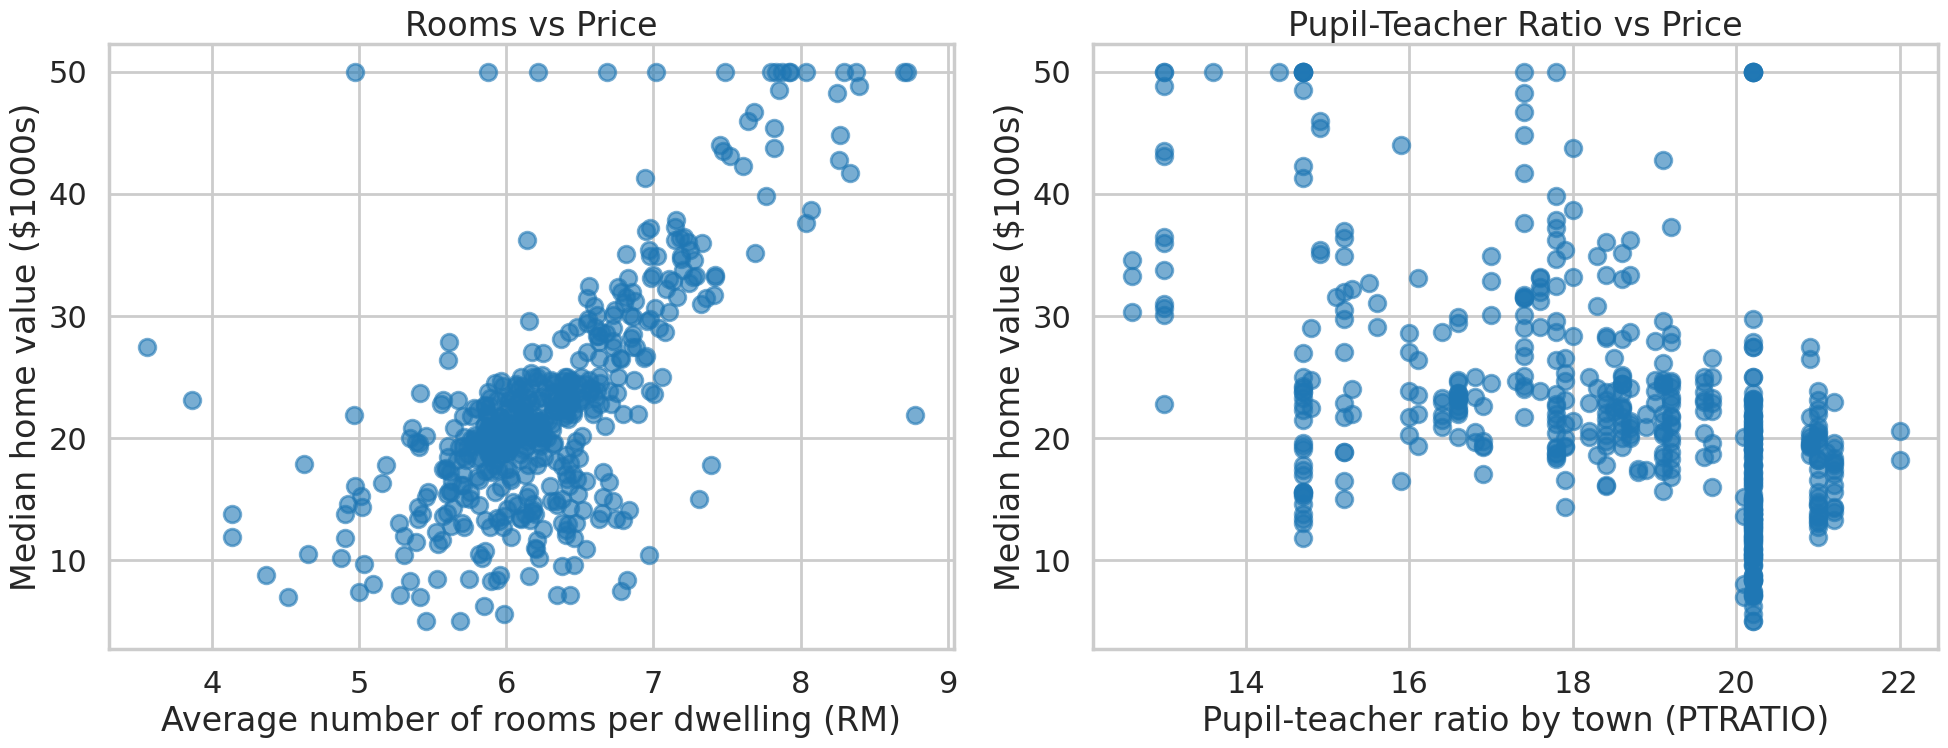

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].scatter(bos.RM, bos.PRICE, alpha=0.6)
axes[0].set_xlabel("Average number of rooms per dwelling (RM)")
axes[0].set_ylabel("Median home value ($1000s)")
axes[0].set_title("Rooms vs Price")

axes[1].scatter(bos.PTRATIO, bos.PRICE, alpha=0.6)
axes[1].set_xlabel("Pupil-teacher ratio by town (PTRATIO)")
axes[1].set_ylabel("Median home value ($1000s)")
axes[1].set_title("Pupil-Teacher Ratio vs Price")

plt.tight_layout()

RM vs PRICE shows a strong positive, roughly linear relationship (r ≈ 0.70). More rooms means a bigger house, which means a higher price. Watch for:

The cap at 50 again, especially among tracts with 7-9 rooms.
A few tracts with RM > 8 whose prices are only in the 20s-30s.
A few tracts with very few rooms (~4-5) but high prices. These may be data anomalies or special neighborhoods.

PTRATIO vs PRICE shows a moderate negative relationship (r ≈ -0.51). Higher student-to-teacher ratios go with cheaper homes, which fits the idea that families pay a premium for well-resourced schools. But:

The points form vertical stripes because PTRATIO is measured per town, so many tracts share the same value.
There's a large cluster at 20.2 with mostly low prices. Those tracts tend to be high-crime, high-tax urban areas, so PTRATIO may partly be a proxy for other disadvantages, not a direct cause.

The story so far: bigger homes cost more, and tracts with weaker schools and higher crime cost less. But no single variable explains price on its own.

<Axes: >

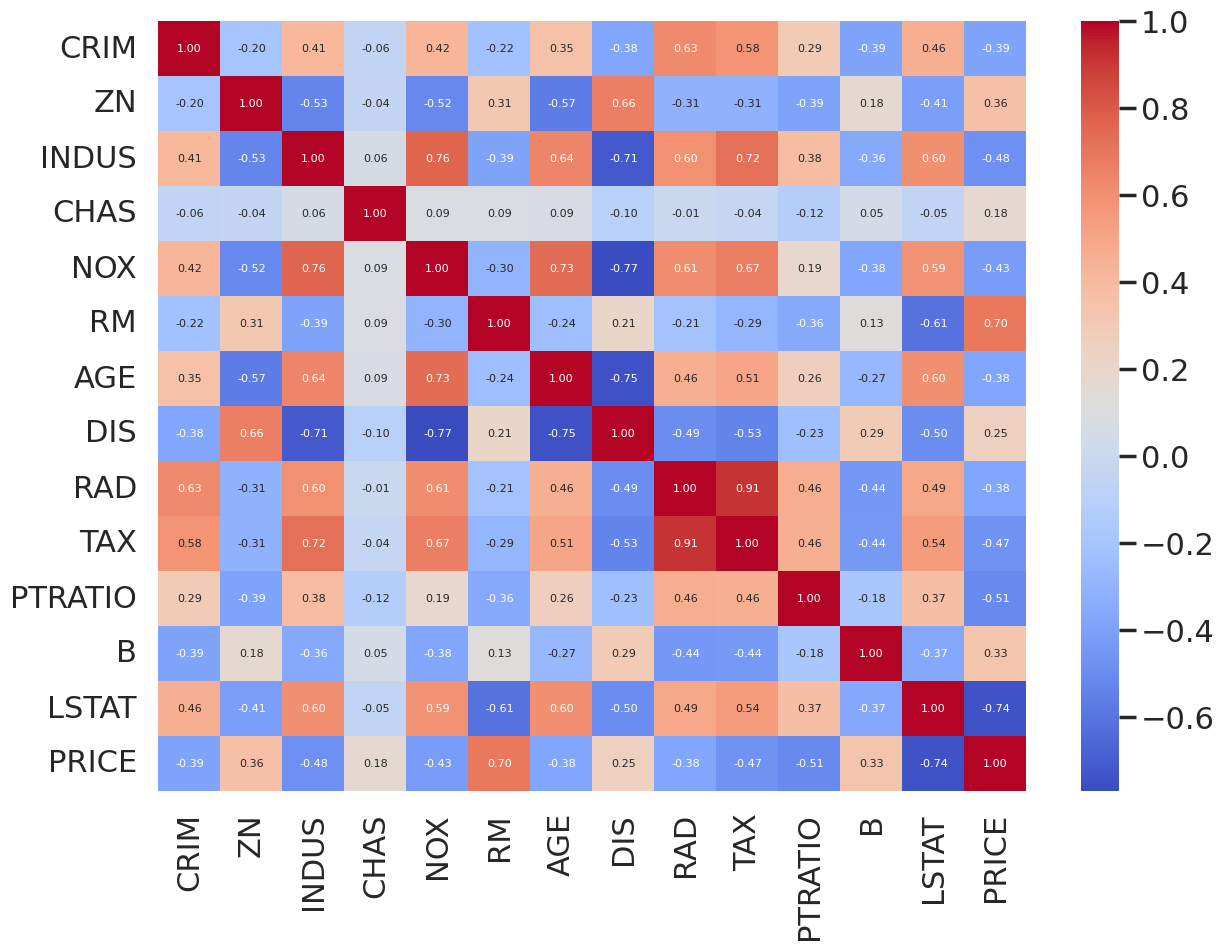

In [7]:
plt.figure(figsize=(14, 10))
sns.heatmap(bos.corr(), annot=True, fmt=".2f", cmap="coolwarm", annot_kws={"size": 8})

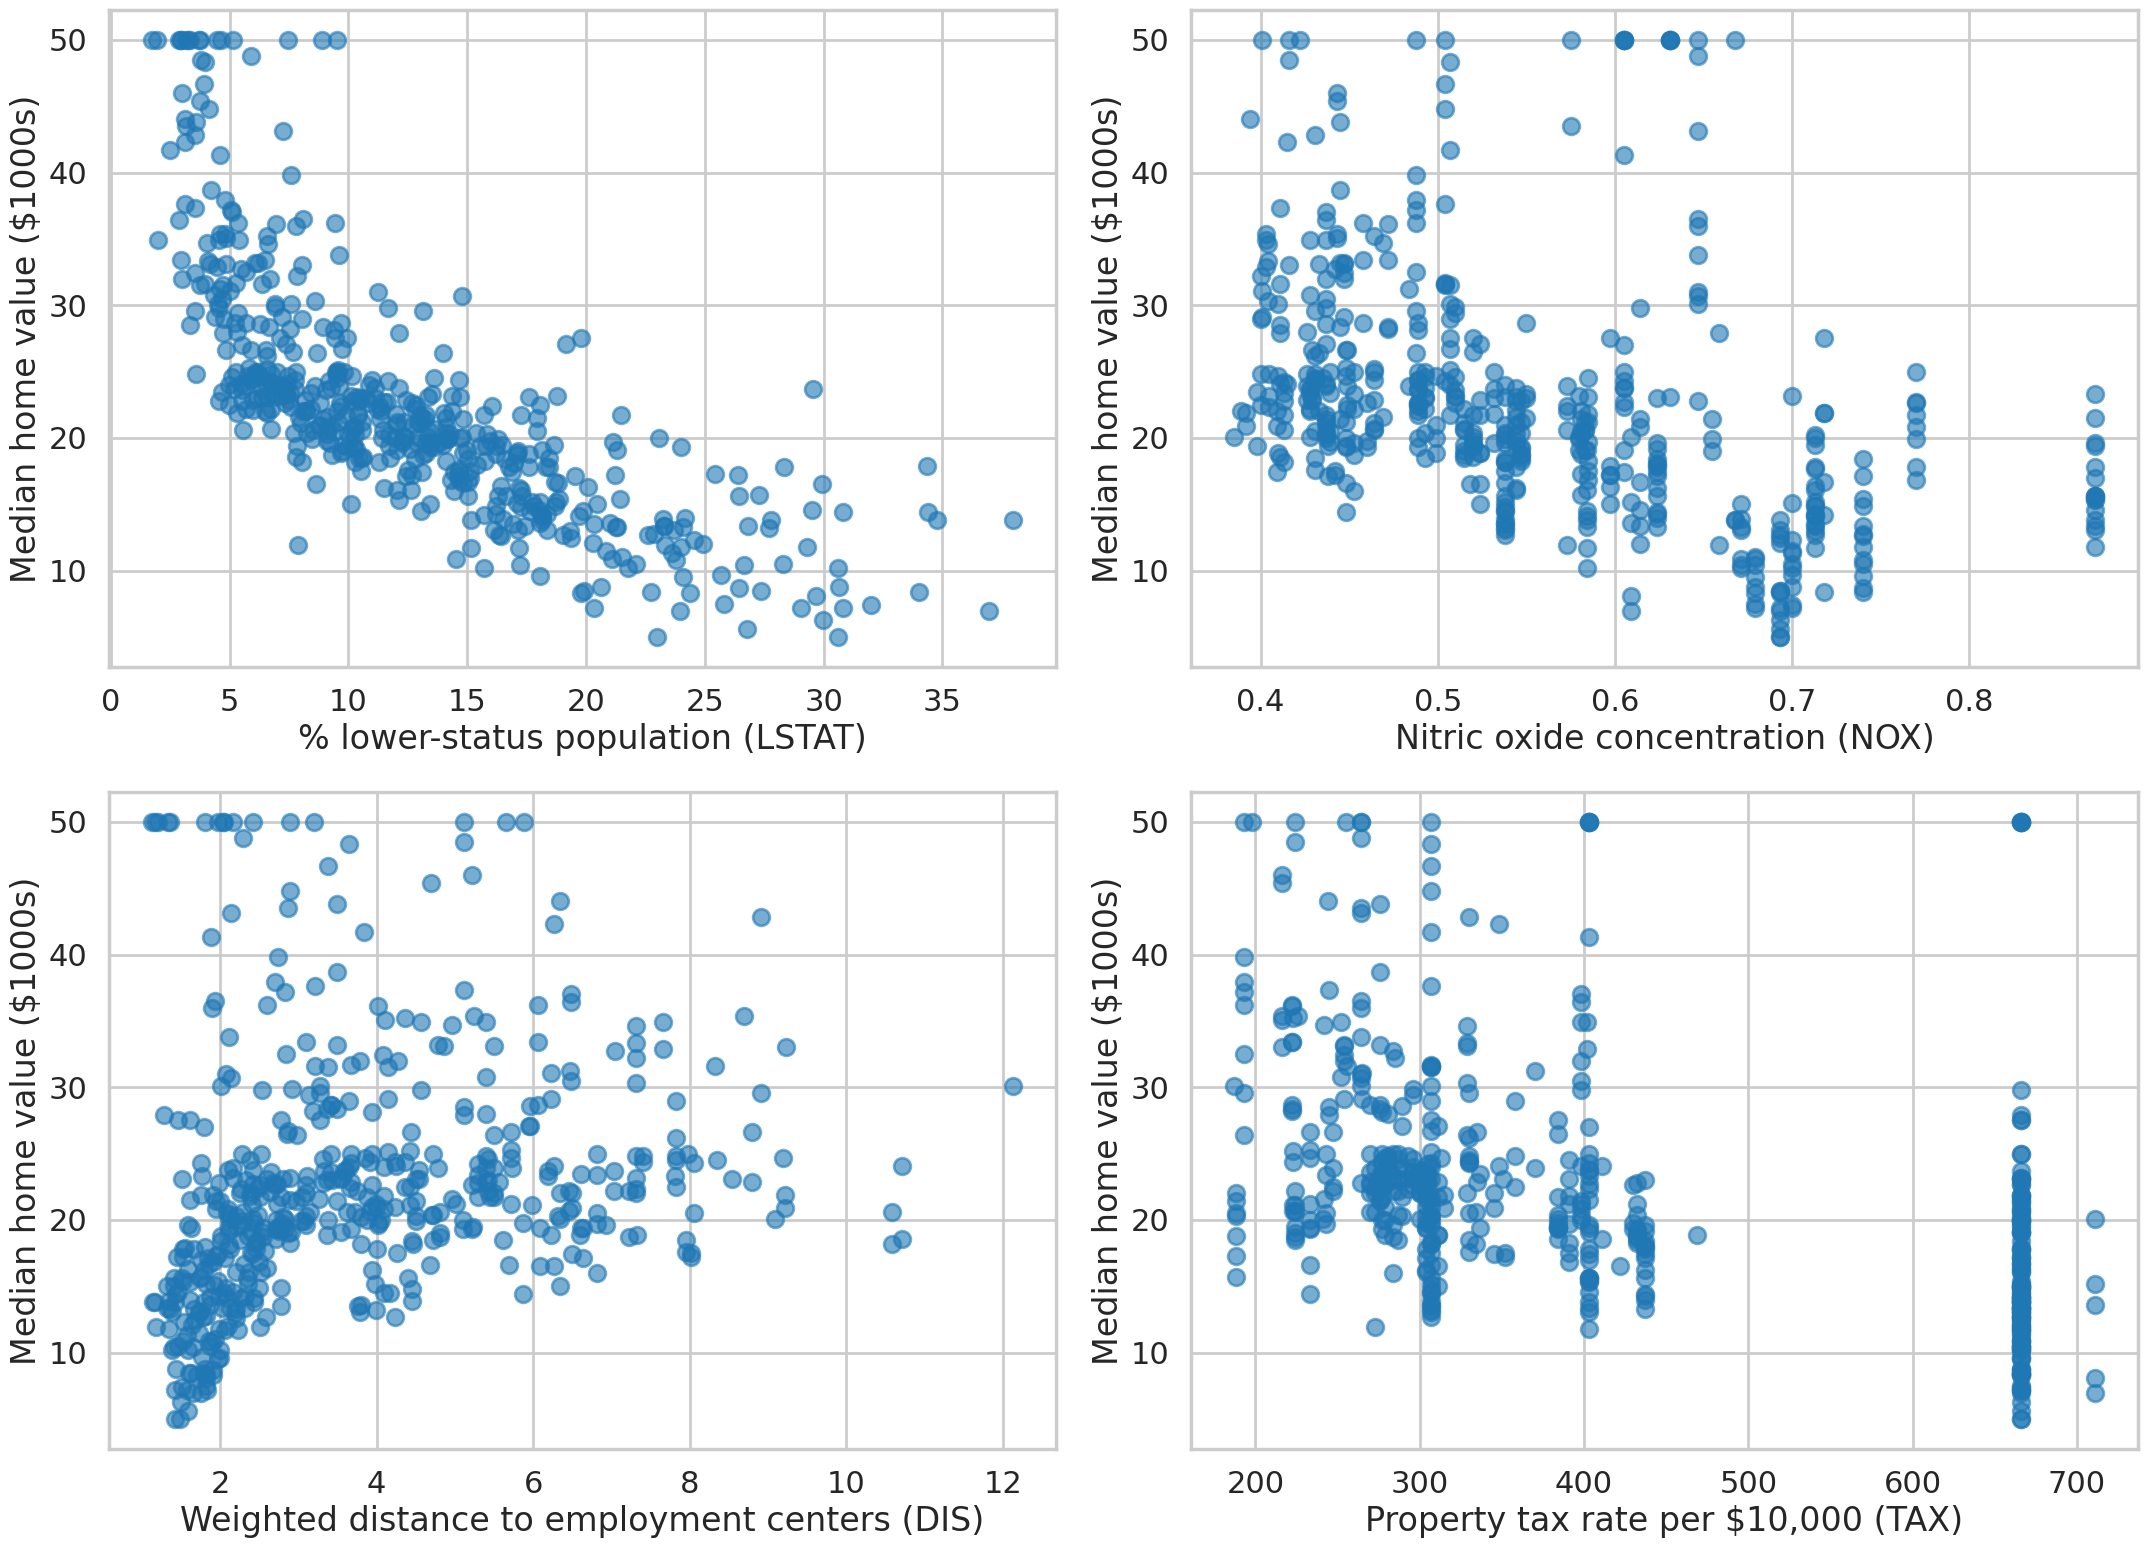

In [8]:
vars_ = {
    "LSTAT": "% lower-status population (LSTAT)",
    "NOX": "Nitric oxide concentration (NOX)",
    "DIS": "Weighted distance to employment centers (DIS)",
    "TAX": "Property tax rate per $10,000 (TAX)",
}

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
for ax, (col, label) in zip(axes.ravel(), vars_.items()):
    ax.scatter(bos[col], bos.PRICE, alpha=0.6)
    ax.set_xlabel(label)
    ax.set_ylabel("Median home value ($1000s)")
plt.tight_layout()

Story: Neighborhood socioeconomic status (LSTAT) is the strongest single predictor, and its curved shape means a log transform may help a regression. Pollution (NOX) and property tax (TAX) are negatively associated with price, but they also correlate with each other and with industrial land use, which points to multicollinearity. Many of the cheapest tracts sit close to job centers, but very high-priced tracts tend to be farther out.

Two caveats:

Correlation isn't causation. Many of these variables move together (crime, pollution, taxes, and poverty cluster in the same urban tracts).
The B column in this dataset is based on a formula involving the proportion of Black residents, and it was built on the assumption that segregation raises home values. Because of this, scikit-learn removed the dataset from its library. It's worth noting in your write-up, and you may want to exclude B from any model.

<Axes: xlabel='RM', ylabel='PRICE'>

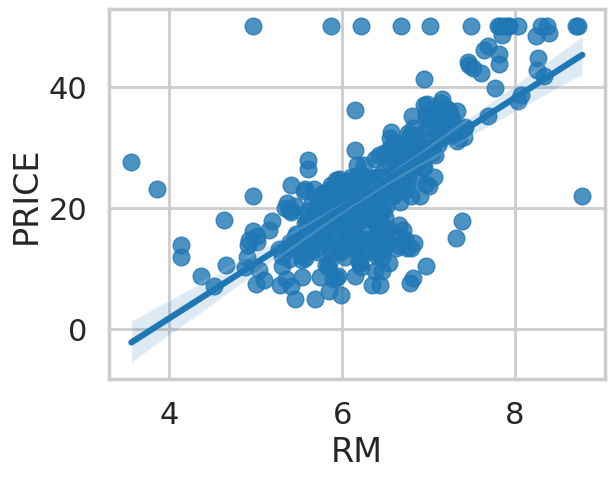

In [9]:
sns.regplot(y="PRICE", x="RM", data=bos, fit_reg = True)

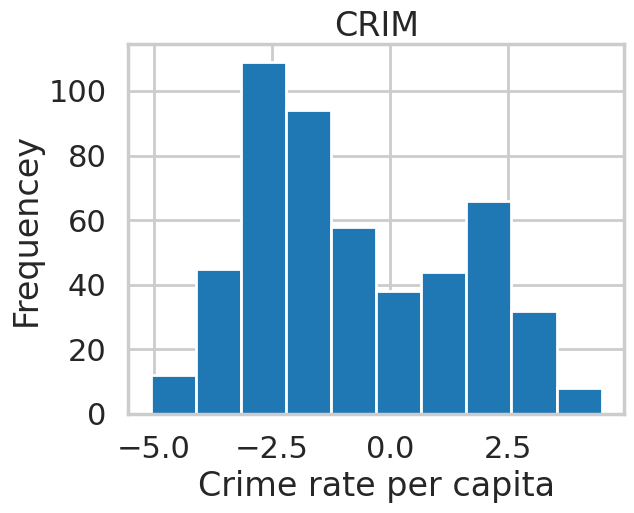

In [10]:
plt.hist(np.log(bos.CRIM))
plt.title("CRIM")
plt.xlabel("Crime rate per capita")
plt.ylabel("Frequencey")
plt.show()

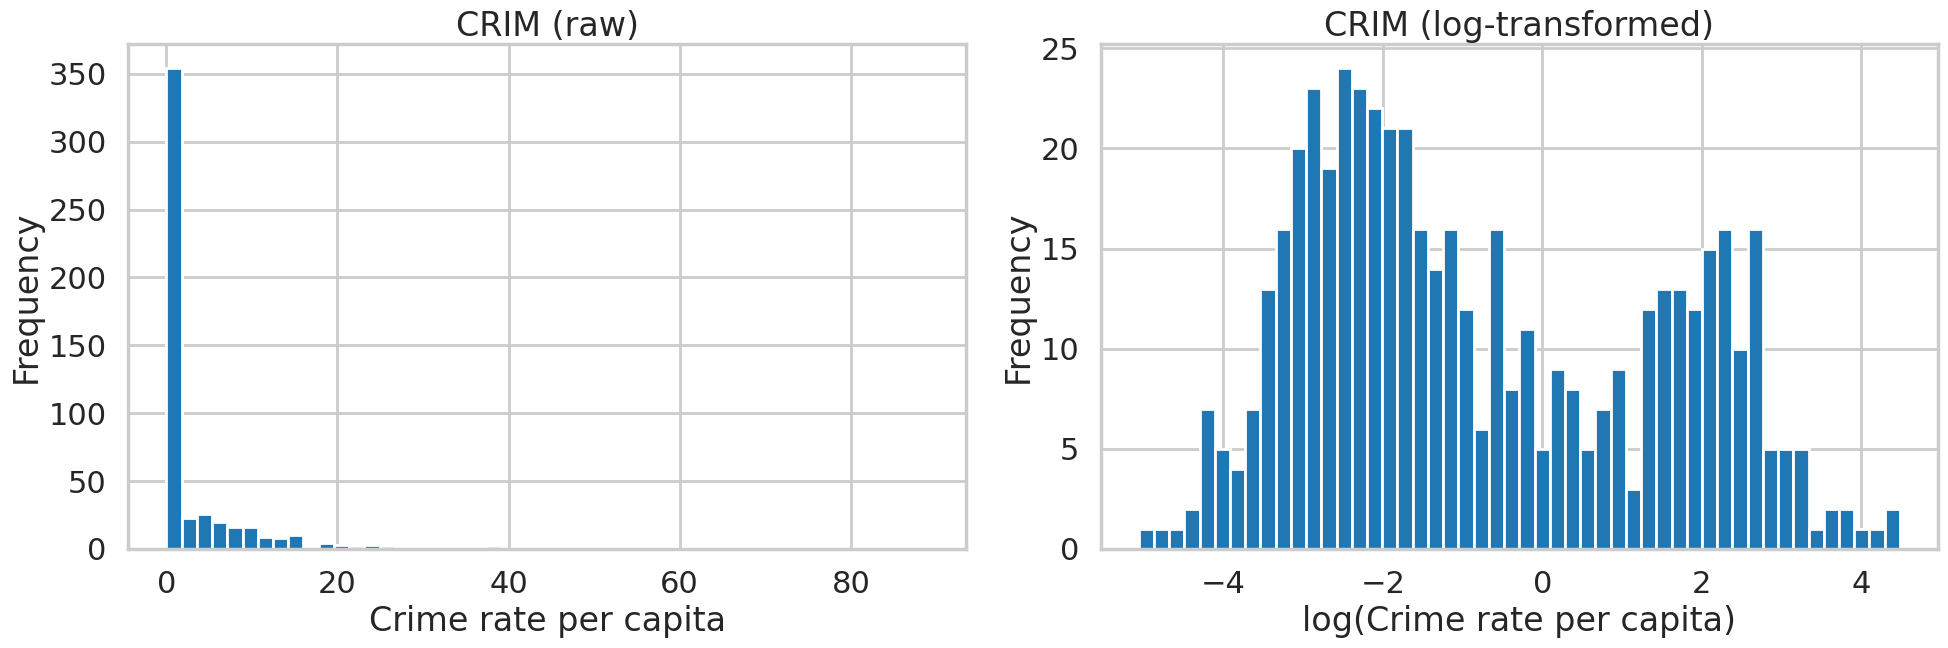

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

axes[0].hist(bos.CRIM, bins=50)
axes[0].set_title("CRIM (raw)")
axes[0].set_xlabel("Crime rate per capita")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log(bos.CRIM), bins=50)
axes[1].set_title("CRIM (log-transformed)")
axes[1].set_xlabel("log(Crime rate per capita)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Raw histogram: Nearly all the data piles up in the first bin or two (crime rates under ~5), with a long thin tail stretching out to about 89. You can't see any structure in the bulk of the data because the few extreme tracts stretch the x-axis.

Purpose of the log transform: CRIM is strongly right-skewed and spans several orders of magnitude (roughly 0.006 to 89). Taking the log compresses the large values and spreads out the small ones, so the distribution becomes far easier to read. Ratios matter more than absolute differences here: going from 0.01 to 0.1 is as meaningful as going from 1 to 10.

What we gain:

The bulk of the data becomes visible instead of being squashed into one bar.
The shape becomes closer to symmetric, which suits methods like linear regression that work best with roughly normal, non-skewed inputs.
The influence of extreme values shrinks.
The relationship with PRICE is closer to linear, since the earlier scatter plot showed exponential-decay-like behavior.

What the log reveals that's not obvious in the raw plot: The log histogram is bimodal (or at least has two clear humps). One group of tracts has very low crime (log CRIM around -5 to -4, i.e. CRIM ≈ 0.01-0.05), and another has moderate-to-high crime (log CRIM around 0 to 2, i.e. CRIM ≈ 1-7). That suggests two distinct kinds of neighborhoods, such as low-crime suburban or residential tracts and higher-crime urban tracts, rather than one smooth continuum. Check this against your own plot, since the exact shape depends on your bin count.

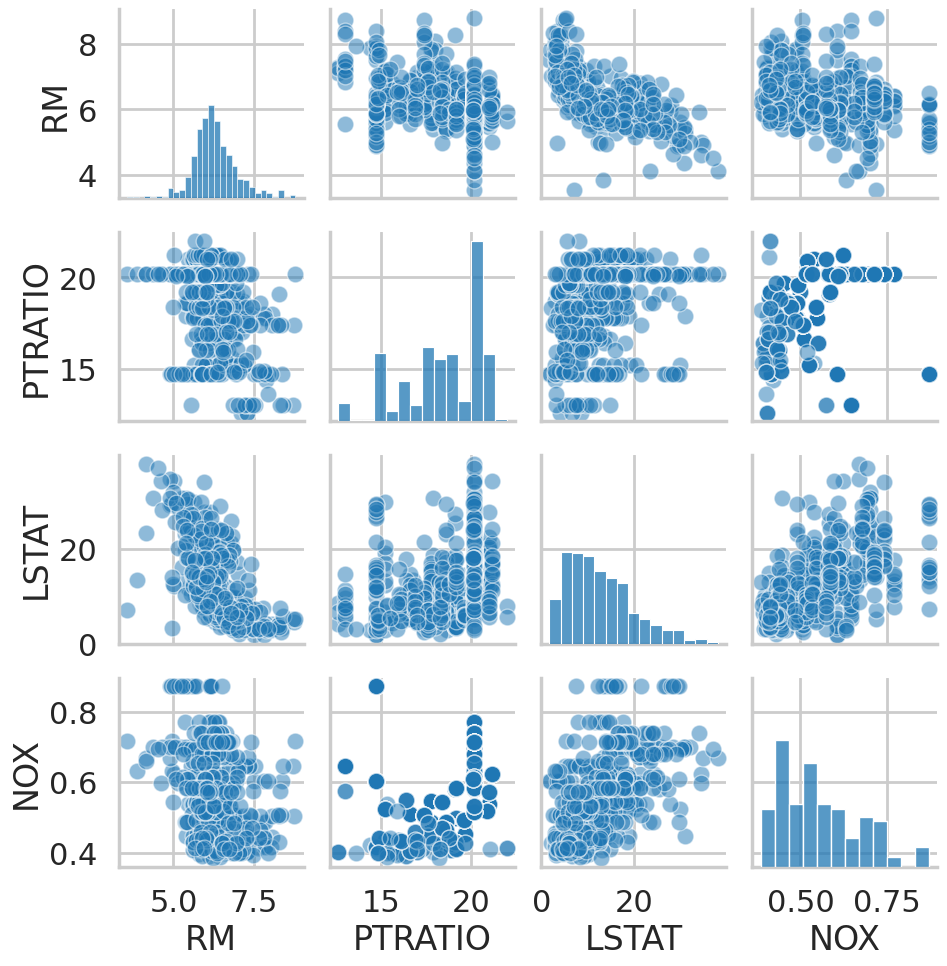

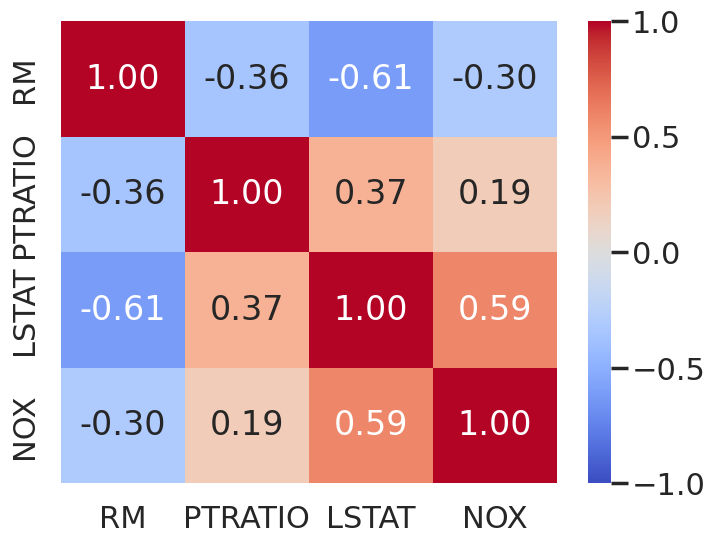

In [12]:
cols = ["RM", "PTRATIO", "LSTAT", "NOX"]

# Pairwise scatter plots and histograms on the diagonal
sns.pairplot(bos[cols], diag_kind="hist", plot_kws={"alpha": 0.5})
plt.show()

# Numeric summary
plt.figure(figsize=(8, 6))
sns.heatmap(bos[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

Approximate correlations you should see:

Pair	r (approx.)	Interpretation
RM vs LSTAT	-0.61	Larger homes are in tracts with fewer lower-status residents. Fairly strong.
RM vs PTRATIO	-0.36	Larger homes tend to be in tracts with better student-teacher ratios. Moderate.
RM vs NOX	-0.30	Weak negative.
PTRATIO vs LSTAT	0.37	Weak-to-moderate positive.
PTRATIO vs NOX	0.19	Weak.
LSTAT vs NOX	0.59	Moderate-to-strong positive. Poorer, more industrial areas have more pollution.


What this means:

The predictors are not independent. RM, LSTAT, and NOX are all moderately correlated with each other, so their effects on PRICE will overlap. In a regression, that's multicollinearity: coefficients become less stable and harder to interpret individually.
PTRATIO is the most "independent" of the four, with only weak-to-moderate links to the rest. It may add somewhat distinct information about price.
Diagonal histograms: RM looks roughly normal, LSTAT is right-skewed, NOX is lumpy, and PTRATIO has a spike at 20.2. Skewed variables like LSTAT are candidates for a log transform, just as with CRIM.

In [13]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [14]:
m = ols('PRICE ~ RM',bos).fit()
print(m.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     471.8
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           2.49e-74
Time:                        03:40:00   Log-Likelihood:                -1673.1
No. Observations:                 506   AIC:                             3350.
Df Residuals:                     504   BIC:                             3359.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -34.6706      2.650    -13.084      0.0

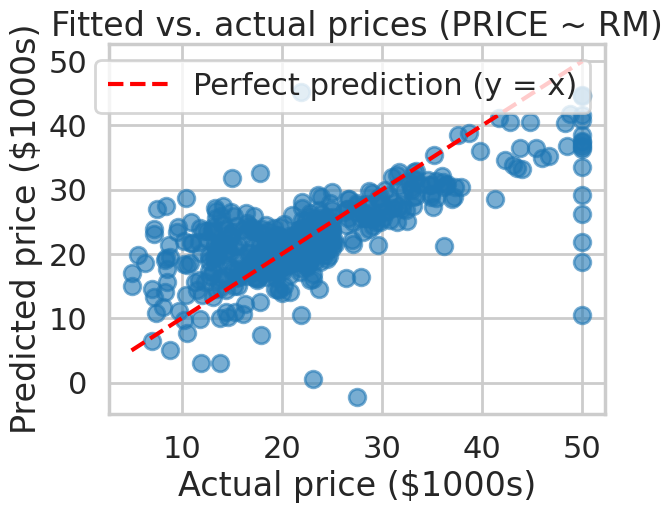

In [15]:
plt.scatter(bos.PRICE, m.fittedvalues, alpha=0.6)
plt.plot([bos.PRICE.min(), bos.PRICE.max()],
         [bos.PRICE.min(), bos.PRICE.max()], "r--", label="Perfect prediction (y = x)")
plt.xlabel("Actual price ($1000s)")
plt.ylabel("Predicted price ($1000s)")
plt.title("Fitted vs. actual prices (PRICE ~ RM)")
plt.legend()
plt.show()

What the plot looks like: There is a positive trend, but the points form a wide, loose cloud around the red line instead of hugging it. If the model were perfect, every point would sit on the diagonal. The moderate R² means RM explains only about half the variation in price.

In [16]:
from sklearn.linear_model import LinearRegression
X = bos.drop('PRICE', axis = 1)

# This creates a LinearRegression object
lm = LinearRegression()
lm

LinearRegression()

In [18]:
lm.fit(X, bos.PRICE)

LinearRegression()

In [19]:
lm_no_int = LinearRegression(fit_intercept=False)
lm_no_int.fit(X, bos.PRICE)

LinearRegression(fit_intercept=False)

Would I recommend it? No, not here.

The intercept absorbs the mean. With an intercept, the fitted plane is forced through the point of means (x̄, ȳ), so the residuals average to zero. Without one, the plane must pass through the origin, and the model has to use the slopes to compensate for any baseline level in PRICE. That biases the coefficients.
The origin isn't meaningful for this data. Regression through the origin only makes sense when you have strong theoretical reasons to believe y = 0 when every predictor is 0. Here, several predictors (like TAX, PTRATIO, NOX) never come anywhere near 0, so "all predictors equal zero" is far outside the data. The intercept here is just a baseline that keeps the fit from being distorted, and it needn't have a physical interpretation.
Diagnostics get misleading. Without an intercept, the residuals no longer necessarily sum to zero, and R² is computed differently (relative to zero rather than to the mean). The resulting R² is often inflated and can't be compared directly with the with-intercept model.
Dropping it when the true intercept isn't zero hurts the fit. Including an unnecessary intercept costs one degree of freedom and slightly widens the uncertainty. Wrongly excluding a needed one causes bias. That asymmetry favors keeping it

No. i.i.d. has two parts, and normality speaks to only one of them.

Identically distributed: every residual comes from the same distribution, with the same mean and the same variance (homoscedasticity). Normality tells you the shape of the distribution, but not that the variance is constant. Residuals could each be normal but with variance that grows with the fitted value. That's the fanning-out pattern we suspected in the PRICE ~ RM model, and it violates "identically."
Independent: knowing one residual tells you nothing about another. Normality says nothing about this. Residuals could be normal but autocorrelated (for example, neighboring tracts having similar errors, or time-series data with serial correlation). Only for a jointly normal, uncorrelated set does uncorrelated imply independent, and uncorrelated is itself something normality doesn't give you.

False.

The assumption concerns the errors (residuals), not the marginal distribution of Y. The model is Y = Xβ + ε, and the normality assumption (when needed at all) is on ε. What is really being assumed is that Y is normal conditional on X, which follows from normal errors.

The marginal distribution of Y can look nothing like a bell curve, even when the model is perfectly valid. For example, if X is bimodal or skewed, Y will inherit that shape through Xβ while the errors remain normal. A quick illustration with this dataset: PRICE is right-skewed and capped at 50, yet the residuals from a good model can still be close to normal.

In [20]:
print('Estimated intercept coefficient: {}'.format(lm.intercept_))

Estimated intercept coefficient: 36.459488385089955


In [21]:
print('Number of coefficients: {}'.format(len(lm.coef_)))

Number of coefficients: 13


In [22]:
pd.DataFrame({'features': X.columns, 'estimatedCoefficients': lm.coef_})[['features', 'estimatedCoefficients']]

,features,estimatedCoefficients
0,CRIM,-0.108011
1,ZN,0.046420
2,INDUS,0.020559
3,CHAS,2.686734
4,NOX,-17.766611
5,RM,3.809865
6,AGE,0.000692
7,DIS,-1.475567
8,RAD,0.306049
9,TAX,-0.012335


In [23]:
# first five predicted prices
lm.predict(X)[0:5]

array([30.00384338, 25.02556238, 30.56759672, 28.60703649, 27.94352423])

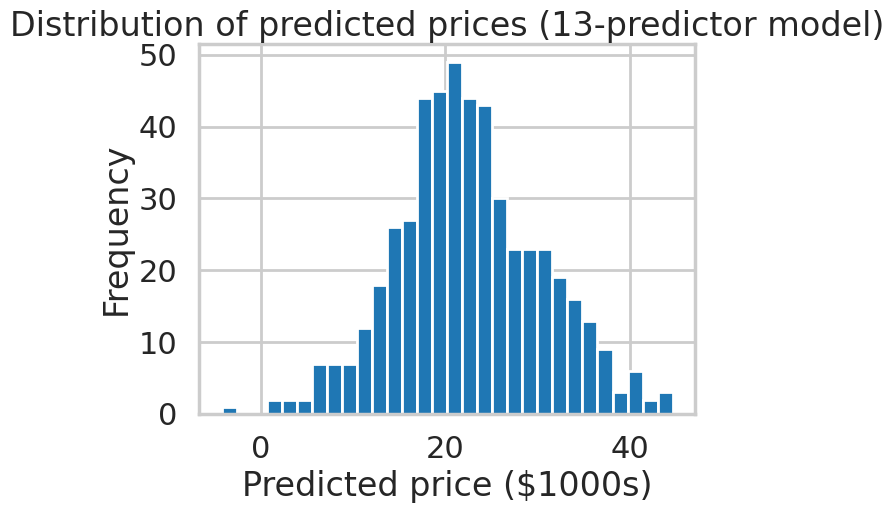

In [24]:
plt.hist(lm.predict(X), bins=30)
plt.xlabel("Predicted price ($1000s)")
plt.ylabel("Frequency")
plt.title("Distribution of predicted prices (13-predictor model)")
plt.show()

Shape: Roughly unimodal and bell-shaped, with a slight right skew. It looks more symmetric than the raw PRICE histogram, and it lacks the spike at 50.

Center: Around 22 (the mean of predicted values equals the mean of PRICE, about 22.5, because OLS with an intercept preserves the mean). The median is close to that.

Spread: Predictions run from about -4 or -5 up to about 40 or so, with most of the mass between roughly 15 and 30. The standard deviation is around 7, which is narrower than the actual PRICE (about 9.2). A regression's fitted values always have less variance than the response, since the residual variance is what's left over.

Outliers:

A handful of negative predicted prices (a few tracts come out around -4 to 0). These are impossible as real prices.
A few predictions in the high 30s to 40s.

Why they happen: The negative predictions come from tracts with extreme predictor values (very high LSTAT, high CRIM, very low RM) where the linear model extrapolates below zero. A straight-line model has no floor. At the top end, the 50 cap means the model never learns what true high-end prices look like, so it underpredicts them.

Should we do anything special? Not delete them blindly. First check whether the corresponding rows are data errors or just extreme but legitimate tracts (look at X[lm.predict(X) < 0]). Then consider options:

Log-transform PRICE, which guarantees positive predictions and often fixes the skew and non-linearity.
Transform skewed predictors (LSTAT, CRIM).
Consider dropping or separately handling the censored rows at exactly 50, since their true values are unknown.
Use a model that captures non-linearity (polynomial terms, tree-based methods).
Report the negative predictions honestly as a limitation instead of quietly clipping them to zero.

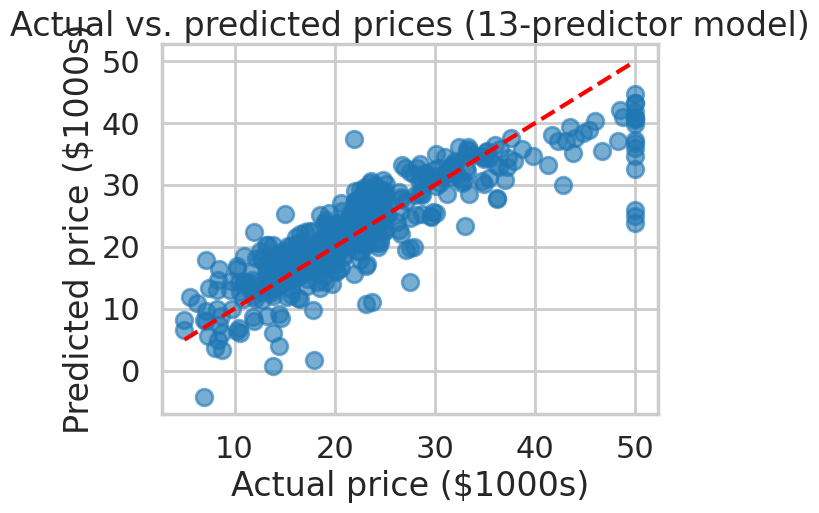

In [25]:
plt.scatter(bos.PRICE, lm.predict(X), alpha=0.6)
plt.plot([bos.PRICE.min(), bos.PRICE.max()],
         [bos.PRICE.min(), bos.PRICE.max()], "r--")
plt.xlabel("Actual price ($1000s)")
plt.ylabel("Predicted price ($1000s)")
plt.title("Actual vs. predicted prices (13-predictor model)")
plt.show()

Advantages of statsmodels: It tells you how confident you can be in each coefficient. From the summary you can see which predictors are statistically significant (for example, INDUS and AGE usually are not significant in the full Boston model), the uncertainty around each coefficient, whether the residuals look normal, and warnings about multicollinearity (the condition number note). That makes it the better choice for interpretation and hypothesis testing.

Advantages of scikit-learn: It's designed for prediction. It plugs into train/test splits, cross-validation, pipelines, and regularized models, so you can measure how well the model generalizes to new data. Note that everything so far has been evaluated on the training data, which overstates performance.

Bottom line: Use statsmodels when you want to understand and explain relationships. Use scikit-learn when you want to build and validate a predictive model. In practice, they are often used together.

In [29]:
print(np.sum((bos.PRICE - lm.predict(X)) ** 2))

11078.784577954977


In [28]:
print(np.sum((lm.predict(X) - np.mean(bos.PRICE)) ** 2))

31637.510837064638


In [30]:
m2 = ols('PRICE ~ PTRATIO', bos).fit()
print(m2.summary())

print("Intercept, slope:", m2.params.values)
print("R^2:", m2.rsquared)
print("F-statistic:", m2.fvalue, " p-value:", m2.f_pvalue)
print("t-statistic (PTRATIO):", m2.tvalues["PTRATIO"])
print("t^2:", m2.tvalues["PTRATIO"] ** 2)

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.256
Method:                 Least Squares   F-statistic:                     175.1
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           1.61e-34
Time:                        04:05:34   Log-Likelihood:                -1764.8
No. Observations:                 506   AIC:                             3534.
Df Residuals:                     504   BIC:                             3542.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     62.3446      3.029     20.581      0.0

Exercise 1: Intercept and coefficient
Intercept (≈ 62.3): The predicted median home value is about 62,300 when PTRATIO = 0. That's not a realistic scenario, since PTRATIO in this data runs from roughly 12.6 to 22.0, so this is an extrapolation. It just anchors the line and shouldn't be taken literally (it's even above the 50 cap).
Coefficient (≈ -2.16): Each additional student per teacher is associated with a median home value about $2,160 lower, on average. This is an association, not a causal effect. PTRATIO is correlated with crime, poverty (LSTAT), and other neighborhood traits, as we saw in the predictor correlations, so it likely partly proxies for them.

R² ≈ 0.258. About 26% of the variation in house prices across tracts is explained by PTRATIO alone. That's meaningful for a single predictor, but 74% is left unexplained, far less than RM (≈ 0.48) or the full model (≈ 0.74). This matches the loose cloud and vertical stripes in the scatterplot from earlier.

F ≈ 175, with a p-value on the order of 10⁻³⁴. The F-statistic compares the model to an intercept-only model:

F = (ESS / p) / (RSS / (n − p − 1))

where p is the number of predictors. Here p = 1 and n − p − 1 = 504. The null hypothesis is that all slope coefficients are zero (PTRATIO explains nothing). A huge F with a tiny p-value means we reject that: the model explains far more variance than chance would, given how much is left unexplained. Note that this says the relationship is statistically significant, not that it's strong or useful for prediction. R² covers strength.

The t-statistic for the PTRATIO coefficient is about -13.2, and squaring it gives ≈ 175, which is the F-statistic:

F = t²

The reason is that in simple regression, the F-test (does the model beat the intercept-only model?) and the t-test (is the single slope zero?) are testing the same null hypothesis, that the slope is zero. They can't disagree, and the p-values are identical. The t-statistic also carries the sign (negative here), which F does not.

This equivalence breaks down with multiple predictors. The F-test then asks whether any slope is nonzero, while each t-test asks about one coefficient given the others. That's why the 13-predictor model can have a huge F even when some individual t-statistics (like INDUS and AGE) are insignificant.

In [31]:
m3 = ols('PRICE ~ CRIM + RM + PTRATIO', bos).fit()
print(m3.summary())

print("F-statistic:", m3.fvalue, " p-value:", m3.f_pvalue)
print("R^2:", m3.rsquared, " adj R^2:", m3.rsquared_adj)
print(m3.params)
print(m3.pvalues)

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     245.2
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           6.15e-98
Time:                        04:10:11   Log-Likelihood:                -1612.0
No. Observations:                 506   AIC:                             3232.
Df Residuals:                     502   BIC:                             3249.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.3707      4.034     -0.836      0.4

Exercise 1: F-statistic

The F-test compares your model against an intercept-only model. The null hypothesis is that CRIM, RM, and PTRATIO all have zero slope. An F around 245 with a vanishingly small p-value means we reject that: at least one of the three predictors is related to price, and the model explains far more variance than chance would.

Two cautions:

It doesn't say which predictors matter. That's the job of the individual t-tests.
It tests significance, not strength or usefulness. R² speaks to strength.

Unlike the PTRATIO-only model, F no longer equals t² for any coefficient, because the F-test is a joint test across three slopes. (You can check that 245 is not 18.4², 6.4², or 8.2².)

Exercise 2: R²

R² ≈ 0.59. About 59% of the variation in house prices across tracts is explained by these three variables together. That's a big improvement over the single-predictor models (RM alone ≈ 0.48, PTRATIO alone ≈ 0.26), but well below the 13-predictor model (0.74). So 41% of the variation is still unexplained.

Use adjusted R² to compare models with different numbers of predictors, since plain R² never decreases when you add a variable. Here the two are nearly identical (0.593 vs 0.591), which tells you all three predictors are earning their place.

Exercise 3: Significance and the story

Significant predictors: All three, at any conventional level (p < 0.001). The intercept is not significant, but that doesn't matter here. It's the predicted price at CRIM = 0, RM = 0, PTRATIO = 0, which is far outside the data, so it functions only as a baseline.

The story (holding the other two variables fixed in each case):

RM (≈ +7.4): Each additional room per dwelling is associated with about 7,400 higher median home value. It has by far the largest t-statistic, so it's the strongest of the three. Bigger homes cost more, which is unsurprising.
PTRATIO (≈ -1.07): Each additional student per teacher is associated with about 1,070 lower median value. Notice this is roughly half the effect in the PTRATIO-only model (-2.16). Much of what PTRATIO seemed to explain alone was really overlap with home size and crime. That's the multicollinearity we saw in the predictor correlations.
CRIM (≈ -0.20): Each additional crime per 1,000 residents is associated with about 200 lower median value. The effect per unit looks small, but CRIM has a huge range (0 to 89), so a tract with a crime rate 20 points above another is predicted to be about $4,000 cheaper. Recall that the CRIM-PRICE relationship was curved, so a straight-line coefficient is only an average of a nonlinear pattern. Using log(CRIM) would likely fit better.

Putting it together: The typical expensive tract has large homes, low crime, and well-staffed schools, while the cheapest tracts combine small homes, higher crime, and crowded classrooms. Size of home dominates, and crime and schools each add an independent but smaller penalty.

Caveats:

These are associations, not causal effects. Lowering a town's student-teacher ratio wouldn't necessarily raise its home values by 1,070 per student.
The price cap at 50 and the nonlinearity in CRIM mean the coefficients are approximate. Check the residuals (m3.resid vs m3.fittedvalues) for patterns.
To test whether the log transform helps, try ols('PRICE ~ np.log(CRIM) + RM + PTRATIO', bos).fit() and compare adjusted R².

In [32]:
from statsmodels.stats.anova import anova_lm

# Reduced model (Part 3)
m3 = ols('PRICE ~ CRIM + RM + PTRATIO', bos).fit()

# Full model: add LSTAT and NOX
m5 = ols('PRICE ~ CRIM + RM + PTRATIO + LSTAT + NOX', bos).fit()
print(m5.summary())

# F-test comparing nested models
print(anova_lm(m3, m5))

# AIC (and BIC, and adjusted R^2 for context)
print("AIC  reduced:", m3.aic, " full:", m5.aic)
print("BIC  reduced:", m3.bic, " full:", m5.bic)
print("Adj R^2 reduced:", m3.rsquared_adj, " full:", m5.rsquared_adj)

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     214.1
Date:                Tue, 29 Sep 2026   Prob (F-statistic):          8.91e-122
Time:                        04:13:13   Log-Likelihood:                -1550.6
No. Observations:                 506   AIC:                             3113.
Df Residuals:                     500   BIC:                             3139.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     17.4689      4.116      4.244      0.0

If the pattern holds, the five-variable model is better on both criteria: the F-test rejects the reduced model, and AIC drops by well over 10. Adjusted R² also rises, so the improvement isn't merely from adding parameters.

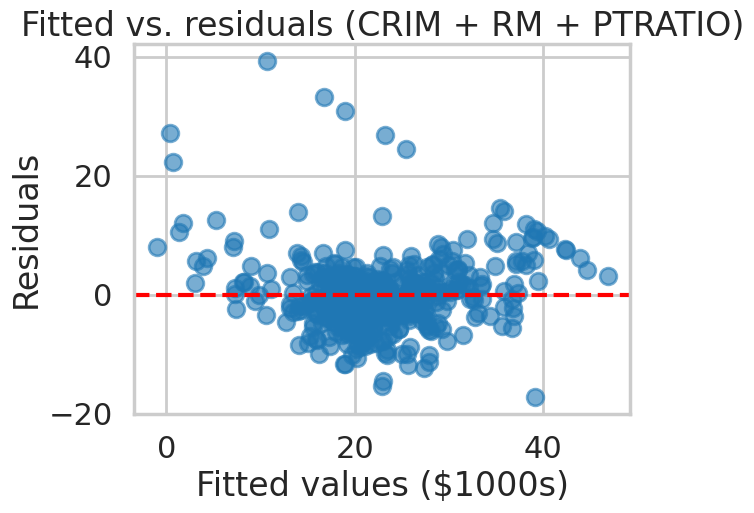

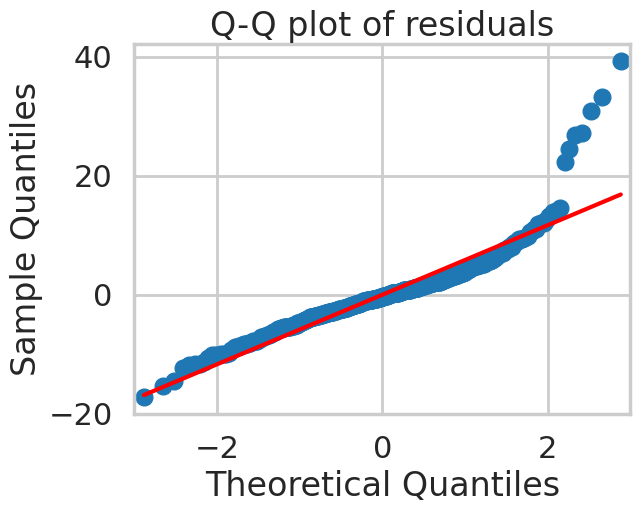

Outliers (|studentized resid| > 3): [364 365 367 368 369 370 371 372]
High leverage (h > 2k/n = 0.0158): [ 97 142 144 147 148 151 152 156 163 196 197 198 204 224 225 232 233 253
 257 258 261 262 263 265 267 268 283 364 365 367 374 375 380 384 386 398
 404 405 406 410 412 413 414 417 418 427]
High Cook's D (> 4/n): [145 161 162 163 166 186 195 203 204 225 228 233 283 364 365 366 367 368
 369 370 371 372 374 375 380 406 410 412 413 414 415 416 418 419 453]


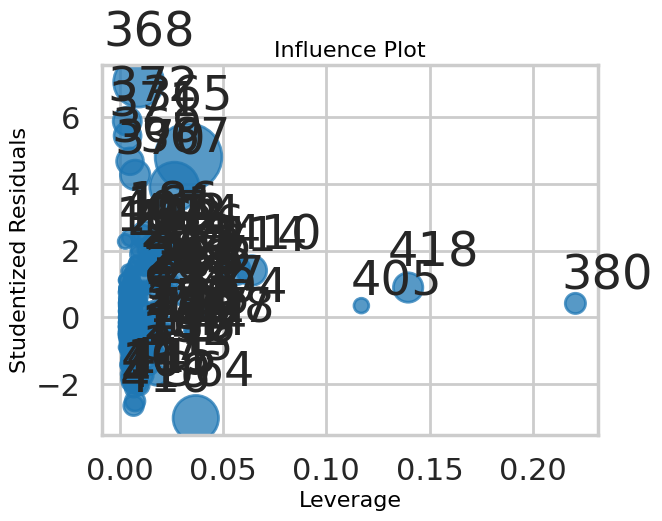

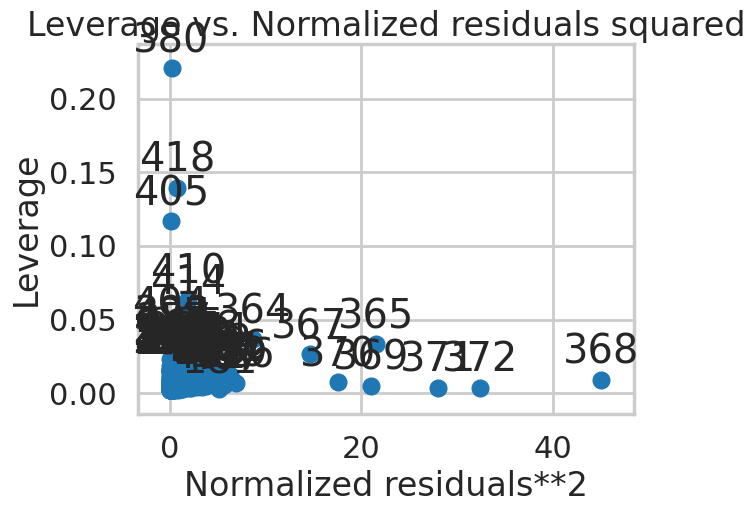

In [33]:
m3 = ols('PRICE ~ CRIM + RM + PTRATIO', bos).fit()

# 1. Fitted vs. residuals
plt.scatter(m3.fittedvalues, m3.resid, alpha=0.6)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Fitted values ($1000s)")
plt.ylabel("Residuals")
plt.title("Fitted vs. residuals (CRIM + RM + PTRATIO)")
plt.show()

# 2. Q-Q plot
sm.qqplot(m3.resid, line="s")
plt.title("Q-Q plot of residuals")
plt.show()

# 3. Influence measures
infl = m3.get_influence()
stud = infl.resid_studentized_external      # studentized residuals
lev = infl.hat_matrix_diag                  # leverage
cooks = infl.cooks_distance[0]              # Cook's distance

n, k = int(m3.nobs), int(m3.df_model) + 1
print("Outliers (|studentized resid| > 3):", np.where(np.abs(stud) > 3)[0])
print("High leverage (h > 2k/n = %.4f):" % (2 * k / n), np.where(lev > 2 * k / n)[0])
print("High Cook's D (> 4/n):", np.where(cooks > 4 / n)[0])

# 4. Leverage / influence plots
sm.graphics.influence_plot(m3, criterion="cooks")
plt.show()
sm.graphics.plot_leverage_resid2(m3)
plt.show()

Exercise 1: Fitted vs. residuals

What to expect: The residuals do not form an even horizontal band around zero.

Curvature. Residuals tend to be positive at low fitted values, negative in the middle, and positive again at high fitted values. That means the linear form is missing some nonlinearity (recall the curved CRIM relationship).
Non-constant variance. The spread is uneven, and it grows toward higher fitted values (a funnel shape), which suggests heteroscedasticity.
A tail of large positive residuals. Tracts with actual prices at the 50 cap, or well above what the model predicts, sit far above zero. Large negative residuals are rarer.
Some negative fitted values at the low end, where the line extrapolates below zero.

Violations: Linearity (the curvature) and constant variance (the funnel). Both undermine the standard errors and p-values, although the coefficients remain unbiased if the mean structure is right, which the curvature suggests it isn't quite.

Exercise 2: Q-Q plot

If the residuals were normal, the points would follow the reference line. Typically here:

The middle follows the line reasonably well.
The upper tail bends sharply upward, so there are more large positive residuals than a normal distribution allows (right skew, heavy right tail).
The lower tail departs somewhat too, but less dramatically.

The residuals are therefore not normal, mainly because of the upper tail. With n = 506, t-tests and F-tests are fairly robust, so this is a moderate problem for inference, but prediction intervals would be unreliable.

Exercise 3: Comparing the two plots

	Fitted vs. residuals	Q-Q plot

Good for

Non-linearity, heteroscedasticity, outliers, and patterns in the errors

Normality of the residuals, tail behavior, and skew

Weak at

Judging normality (hard to see a distribution shape in a scatter)

Everything else: it says nothing about linearity, constant variance, or independence

Reading it

Needs a look for patterns, which is somewhat subjective

Straightforward: on the line or not, but departures are hard to quantify

They are complementary. A model can pass the Q-Q plot and still have a funnel pattern, and vice versa, so check both.

Exercise 4: Outliers

Outliers here are tracts whose price is far from what CRIM, RM, and PTRATIO predict (|studentized residual| > 3). Typically they fall in two groups:

Large positive residuals. These are mostly tracts at or near the 50 cap with moderate room counts, and tracts with unusually high prices for their RM. They could be prestigious neighborhoods, waterfront or downtown-adjacent areas, or places where factors outside the model (proximity to jobs, low LSTAT) push prices up. Some of the 50s are also censored values, so the true price is unknown.
Large negative residuals. These are tracts with high RM but modest prices, perhaps big old homes in declining areas, or areas with high poverty (LSTAT) that the model doesn't see.

Exercise 5: Leverage

Leverage measures how unusual a tract's predictor values are, regardless of its price. The rule of thumb flags h > 2k/n = 8/506 ≈ 0.016. You'd typically see:

Extreme CRIM. A small group of tracts with crime rates far above the rest (CRIM 40-89) are mostly high-crime inner-city areas, and the most extreme have low prices.
Extreme RM. A tract with RM around 3.56 (a very small average dwelling but a relatively high price, if I'm recalling the row correctly, near index 365) and tracts with RM above 8.5.

These are unusual because they are rare, not because they are wrong. Their influence on the fitted line is large: the few very high-crime tracts anchor the CRIM slope. Points that are both high-leverage and have large residuals, which Cook's distance and the bubble size in influence_plot flag, are the ones that actually pull the fit.

In [34]:
bad = np.where((np.abs(stud) > 3) | (lev > 2 * k / n) | (cooks > 4 / n))[0]
print("Removing", len(bad), "rows")

bos_clean = bos.drop(bos.index[bad])
m3_clean = ols('PRICE ~ CRIM + RM + PTRATIO', bos_clean).fit()

comparison = pd.DataFrame({
    "original": m3.params,
    "cleaned": m3_clean.params,
})
print(comparison)
print("R^2   :", m3.rsquared, m3_clean.rsquared)
print("Adj R2:", m3.rsquared_adj, m3_clean.rsquared_adj)
print("F     :", m3.fvalue, m3_clean.fvalue)
print("AIC   :", m3.aic, m3_clean.aic)
print("RMSE  :", np.sqrt(m3.mse_resid), np.sqrt(m3_clean.mse_resid))

Removing 64 rows
           original    cleaned
Intercept -3.370704 -10.868234
CRIM      -0.204961  -0.507382
RM         7.380411   7.814676
PTRATIO   -1.069546  -0.813665
R^2   : 0.5943412940723474 0.7030245941281215
Adj R2: 0.5919170388576402 0.7009905160057113
F     : 245.16449030064646 345.62320216842306
AIC   : 3231.9451235449956 2433.699386812511
RMSE  : 5.875236219728535 3.779572030895263


What to expect:

R² and adjusted R² go up (perhaps from ≈ 0.59 into the high 0.6s), and residual standard error drops, since the hardest-to-fit points are gone.
The CRIM coefficient changes the most (typically it gets smaller in magnitude), because the extreme-crime tracts had a large pull on it.
RM and PTRATIO change moderately but keep their signs, so the story (bigger homes cost more, crowded schools and crime cost less) holds up.
F rises, and standard errors shrink.
The residual plots look better but not perfect, and the curvature will probably remain.

Cautions:

Better R² after deleting points is partly by construction. It is not proof the model is better, and you can't compare the two R² values as if they described the same data.
Deletion needs a reason beyond "it doesn't fit." Data errors and censored values (the 50 cap) are justified reasons. Real but unusual neighborhoods are not, unless you are explicit that the model applies only to typical tracts.
Report both fits so readers can see how sensitive the conclusions are.
Rerunning diagnostics on the cleaned model will flag new points. Don't iterate until nothing is left.
Transforming CRIM (np.log(CRIM)) or PRICE often fixes more than deletion does, so try ols('np.log(PRICE) ~ np.log(CRIM) + RM + PTRATIO', bos) and re-run the diagnostics.